In [1]:
from shared.main import * 

<h1 align='center'> Main behavioral patterns to capture</h1>

Right now, I am thinking of this as being simply a running mean of and the running cosine distance between choice vectors

- delta rule to compute the running mean (mean resultant)
- leaky integrator to integrate over previous trials
- cosine distance between choice vectors is essentially the magnitude of the mean resultant 

Then, the end average location is the final map, where distance can lead to post-task interference

This is very similar to common cause, so I want to make sure I use both projects to support each other

## Visualize basic possible features

In [ ]:
from matplotlib import gridspec
Array = np.ndarray

#---------------------------- general helpers

def normalize_rows(X: Array, eps: float = 1e-8) -> Array:
    X = np.asarray(X, dtype=float)
    return X / (np.linalg.norm(X, axis=1, keepdims=True) + eps)

#---------------------------- plotting helpers

def plot_unit_circle(ax, lim=1.05):
    th = np.linspace(0, 2*np.pi, 256)
    ax.plot(np.cos(th), np.sin(th), linewidth=1, alpha=1, color="black")
    ax.axhline(0, linewidth=1, alpha=1, color="black")
    ax.axvline(0, linewidth=1, alpha=1, color="black")
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)

def plot_xy_grid(ax, lim):
    ax.axhline(0, linewidth=1, alpha=1, color="black")
    ax.axvline(0, linewidth=1, alpha=1, color="black")
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)

def _finite_rows(A):
    A = np.asarray(A, float)
    return (A.ndim == 2) and np.isfinite(A).all(axis=1)

def _pick_idx(path, every):
    T = len(path)
    return np.arange(0, T, int(every))

def plot_running_stats_grid(
    stats,
    *,
    every=2,
    title_suffix="",
    stats2=None,
    title_suffix2=" (alt)",
    palette1="Reds",
    palette2="Blues",
    line_color1="red",
    line_color2="blue",
):
    """
    Plot your 2-column diagnostic figure.
    If stats2 is provided (e.g., leaky vs exact), it overlays the second run.

    Expects in `stats`:
      - X (T,2)
      - mu_raw (T,2)
      - res_dir_unit (T,2)
      - run_cosdist_choices (T,)
      - mrl (T,)
    """

    # ----------------------------
    # Unpack primary stats
    # ----------------------------
    X = np.asarray(stats["X"], float)
    MU_raw = np.asarray(stats["mu_raw"], float)
    RES_dir_unit = np.asarray(stats["res_dir_unit"], float)

    run_cosdist_choices = np.asarray(stats["run_cosdist_choices"], float)
    mrl = np.asarray(stats["mrl"], float)

    idx = _pick_idx(X, every=every)

    # ----------------------------
    # Column specs (match your layout)
    # ----------------------------
    col_specs = [
        dict(
            title="Raw: running mean location" + title_suffix,
            base=X,
            path=MU_raw,
            path_metric="euclidean",
            scalar=run_cosdist_choices,
            scalar_metric="euclidean",
            ylabel="avg pairwise cos dist (choices)",
            space="raw",
            draw_line=True,
        ),
        dict(
            title="Direction-only: running resultant direction" + title_suffix,
            base=RES_dir_unit,
            path=RES_dir_unit,
            path_metric="cosine",
            scalar=mrl,
            scalar_metric="euclidean",
            ylabel="MRL = ||resultant||",
            space="unit",
            draw_line=True,
        ),
    ]

    ncols = len(col_specs)

    fig = plt.figure(figsize=(4.8 * ncols, 8))
    gs = gridspec.GridSpec(
        nrows=3,
        ncols=2 * ncols,
        height_ratios=[4, 1, 2],
        hspace=0.35,
        wspace=0.35,
    )

    # Optional: unpack secondary stats for overlay
    if stats2 is not None:
        X2 = np.asarray(stats2["X"], float)
        MU_raw2 = np.asarray(stats2["mu_raw"], float)
        RES_dir_unit2 = np.asarray(stats2["res_dir_unit"], float)
        run_cosdist_choices2 = np.asarray(stats2["run_cosdist_choices"], float)
        mrl2 = np.asarray(stats2["mrl"], float)

        col_specs2 = [
            dict(base=X2, path=MU_raw2, scalar=run_cosdist_choices2),
            dict(base=RES_dir_unit2, path=RES_dir_unit2, scalar=mrl2),
        ]
    else:
        col_specs2 = None

    for j, spec in enumerate(col_specs):
        c0 = 2 * j

        # ---- top: scatter + path (span 2 subcolumns)
        ax_top = fig.add_subplot(gs[0, c0:c0+2])

        base = np.asarray(spec["base"], float)
        path = np.asarray(spec["path"], float)

        # base scatter (light)
        if base.ndim == 2 and base.shape[1] == 2:
            base_ok = _finite_rows(base)
            sns.scatterplot(
                x=base[base_ok, 0], y=base[base_ok, 1],
                ax=ax_top, s=18, alpha=0.20, linewidth=0, legend=False
            )

        # path snapshots (colored by time)
        use_idx = idx[idx < len(path)]
        path_ok = _finite_rows(path[use_idx])
        use_idx_ok = use_idx[path_ok]  # consistent idx for all subpanels below

        if use_idx_ok.size > 0:
            sns.scatterplot(
                x=path[use_idx_ok, 0], y=path[use_idx_ok, 1],
                hue=use_idx_ok, palette=palette1,
                ax=ax_top, s=80, alpha=1, linewidth=0.5, legend=False, zorder=10
            )
            if spec.get("draw_line", True) and use_idx_ok.size > 1:
                ax_top.plot(
                    path[use_idx_ok, 0], path[use_idx_ok, 1],
                    linewidth=1, alpha=0.5, color=line_color1
                )

        # Optional overlay (second stats)
        if col_specs2 is not None:
            path2 = np.asarray(col_specs2[j]["path"], float)
            use_idx2 = idx[idx < len(path2)]
            ok2 = _finite_rows(path2[use_idx2])
            use_idx2_ok = use_idx2[ok2]

            if use_idx2_ok.size > 0:
                sns.scatterplot(
                    x=path2[use_idx2_ok, 0], y=path2[use_idx2_ok, 1],
                    hue=use_idx2_ok, palette=palette2,
                    ax=ax_top, s=55, alpha=0.9, linewidth=0.5, legend=False, zorder=11
                )
                if spec.get("draw_line", True) and use_idx2_ok.size > 1:
                    ax_top.plot(
                        path2[use_idx2_ok, 0], path2[use_idx2_ok, 1],
                        linewidth=1, alpha=0.45, color=line_color2
                    )

        ax_top.set_title(spec["title"])

        # axes styling
        if spec["space"] == "raw":
            lim = 1.05 * np.nanmax(np.abs(np.vstack([X, MU_raw])))
            plot_xy_grid(ax_top, lim)
            ax_top.set_xlabel("x1")
            ax_top.set_ylabel("x2")
        else:
            plot_xy_grid(ax_top, 1.05)
            plot_unit_circle(ax_top, lim=1.05)
            ax_top.set_xlabel("u1")
            ax_top.set_ylabel("u2")

        # ---- middle: scalar over trials (span 2 subcolumns)
        ax_mid = fig.add_subplot(gs[1, c0:c0+2])
        y = np.asarray(spec["scalar"], float)
        t = np.arange(len(y))
        ax_mid.plot(t, y, linewidth=2, alpha=0.9, color=line_color1)
        ax_mid.scatter(idx, y[idx], s=30, alpha=0.9, color=line_color1)

        if col_specs2 is not None:
            y2 = np.asarray(col_specs2[j]["scalar"], float)
            t2 = np.arange(len(y2))
            ax_mid.plot(t2, y2, linewidth=2, alpha=0.75, color=line_color2)
            ax_mid.scatter(idx, y2[idx], s=22, alpha=0.75, color=line_color2)

        ax_mid.set_xlabel("trial")
        ax_mid.set_ylabel(spec["ylabel"])

        # ---- bottom-left: distance matrix for vector path
        ax_dm_path = fig.add_subplot(gs[2, c0])
        V = np.asarray(spec["path"][use_idx_ok], float)
        if V.shape[0] >= 2:
            Dp = pairwise_distances(V, metric=spec["path_metric"])
            sns.heatmap(Dp, ax=ax_dm_path, cbar=False)
        else:
            ax_dm_path.text(0.5, 0.5, "insufficient\nvalid points",
                            ha="center", va="center")
            ax_dm_path.set_xticks([]); ax_dm_path.set_yticks([])
        ax_dm_path.set_title(f"D(path): {spec['path_metric']}")
        ax_dm_path.set_xticks([]); ax_dm_path.set_yticks([])

        # ---- bottom-right: distance matrix for scalar
        ax_dm_scalar = fig.add_subplot(gs[2, c0+1])
        svec = np.asarray(spec["scalar"][idx], float).reshape(-1, 1)
        Ds = pairwise_distances(svec, metric=spec["scalar_metric"])
        sns.heatmap(Ds, ax=ax_dm_scalar, cbar=False)
        ax_dm_scalar.set_title(f"D(scalar): {spec['scalar_metric']}")
        ax_dm_scalar.set_xticks([]); ax_dm_scalar.set_yticks([])

    # legend note (simple)
    if stats2 is not None:
        fig.suptitle(f"Overlay: primary{title_suffix} (red) vs secondary{title_suffix2} (blue)",
                     y=0.99, fontsize=12)

    plt.show()
    return fig

#---------------------------- running stats computations

def running_mean(X: Array) -> Array:
    X = np.asarray(X, dtype=float)
    if X.ndim != 2:
        raise ValueError(f"X must be 2D; got {X.shape}")
    csum = np.cumsum(X, axis=0)
    t = np.arange(1, X.shape[0] + 1)[:, None]
    return csum / t

def running_avg_cosdist_to_current(DIRS: Array, valid: Array, eps: float = 1e-8) -> Array:
    """
    For each t, compute average cosine distance between DIRS[t] and DIRS[i] for i<t and valid[i]=True.
    DIRS: (T,2) float
    valid: (T,) bool
    """
    DIRS = np.asarray(DIRS, dtype=float)
    valid = np.asarray(valid, dtype=bool).reshape(-1)  # FORCE 1D

    if DIRS.ndim != 2 or DIRS.shape[1] != 2:
        raise ValueError(f"DIRS must be (T,2); got {DIRS.shape}")
    T = DIRS.shape[0]
    if valid.shape != (T,):
        raise ValueError(f"valid must be shape (T,), got {valid.shape} for T={T}")

    out = np.full(T, np.nan, dtype=float)

    for t in range(T):
        if not valid[t]:
            continue

        prev_idx = np.flatnonzero(valid[:t])
        if prev_idx.size == 0:
            out[t] = 0.0
            continue

        # cosine sim between DIRS[t] and each previous DIRS[prev_idx]
        sims = DIRS[prev_idx] @ DIRS[t]
        out[t] = float(np.mean(1.0 - sims))

    return out

def running_avg_pairwise_cosdist_unit(U: Array, valid: Array, eps: float = 1e-8) -> Array:
    """
    For each t, compute mean pairwise cosine distance among unit vectors U[:t+1]
    restricted to valid entries.

    Uses MRL identity for unit vectors:
      mean_sim = (n*mrl^2 - 1)/(n-1),  mean_dist = 1 - mean_sim
    where mrl = ||mean(U)|| and n is the number of valid vectors in the prefix.
    """
    U = np.asarray(U, dtype=float)
    valid = np.asarray(valid, dtype=bool).reshape(-1)
    if U.ndim != 2 or U.shape[1] != 2:
        raise ValueError(f"U must be (T,2); got {U.shape}")
    T = U.shape[0]
    if valid.shape != (T,):
        raise ValueError(f"valid must be (T,); got {valid.shape}")

    # cumulative sum of U (treat invalid as 0 contribution)
    U_fill = np.zeros_like(U)
    U_fill[valid] = U[valid]
    csum = np.cumsum(U_fill, axis=0)

    # effective counts per prefix
    n = np.cumsum(valid.astype(int))

    # running mean of unit vectors over valid samples
    mean_u = np.zeros_like(U)
    nz = n > 0
    mean_u[nz] = csum[nz] / n[nz, None]

    mrl = np.linalg.norm(mean_u, axis=1)  # resultant length of mean direction

    # convert MRL -> mean pairwise cosine distance with correct n
    return cosdist_from_mrl(mrl, n_eff=n)

def decompose_vectors(V: Array, eps: float = 1e-8) -> tuple[Array, Array]:
    V = np.asarray(V, dtype=float)
    mag = np.linalg.norm(V, axis=1)
    direction = V / (mag[:, None] + eps)
    return mag, direction

def cosdist_from_mrl(mrl: Array, n_eff: Array | None = None) -> Array:
    """
    If n_eff is provided, it is the effective sample size for each prefix (e.g., number
    of valid unit-direction samples so far). This matters with real data when some
    x_t have ||x_t||~0 and are excluded from direction-only stats.
    """
    mrl = np.asarray(mrl, dtype=float)
    T = mrl.shape[0]
    if n_eff is None:
        n = np.arange(1, T + 1, dtype=float)
    else:
        n = np.asarray(n_eff, dtype=float)
        if n.shape != (T,):
            raise ValueError(f"n_eff must be shape (T,), got {n.shape}")

    out = np.zeros(T, dtype=float)
    mask = n > 1
    mean_sim = np.zeros(T, dtype=float)
    mean_sim[mask] = (n[mask] * (mrl[mask] ** 2) - 1.0) / (n[mask] - 1.0)
    out[mask] = 1.0 - mean_sim[mask]
    out[~mask] = 0.0
    return out

def rowwise_cosine(A: Array, B: Array, eps: float = 1e-8) -> Array:
    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float)
    num = np.sum(A * B, axis=1)
    den = (np.linalg.norm(A, axis=1) + eps) * (np.linalg.norm(B, axis=1) + eps)
    return num / den

def compute_running_stats(
    X: Array,
    eps: float = 1e-8,
    dir_eps: float = 1e-6,
    debug: bool = False,
) -> dict:
    """
    Column A (raw-space / location):
      - mu_raw: (T,2) running mean of raw choices (location-like, unnormalized)
      - run_cosdist_choices: (T,) running avg pairwise cosine distance among CHOICES
        (computed on unit-normalized choices, restricted to valid_dir)

    Column B (direction-only / resultant):
      - res_dir: (T,2) running mean of unit directions (inside unit disk)
      - res_dir_unit: (T,2) unit direction of res_dir (NaN where undefined)
      - mrl: (T,) ||res_dir|| in [0,1]

    Extras:
      - U: (T,2) unit choices (NaN where invalid)
      - valid_dir, n_dir
      - run_cosdist_mrl: (T,) mean pairwise cosine distance implied by MRL (same info as mrl)
      - align_raw_vs_dir: cosine(mu_raw_dir_unit, res_dir_unit)
    """
    X = np.asarray(X, dtype=float)
    if X.ndim != 2 or X.shape[1] != 2:
        raise ValueError(f"X must be (T,2); got {X.shape}")
    if not np.all(np.isfinite(X)):
        raise ValueError("X contains non-finite values")

    T = X.shape[0]

    # ---- Column A vector: raw running mean location
    mu_raw = running_mean(X)

    # ---- Unit directions of choices (shared basis for cosine stats)
    x_norm = np.linalg.norm(X, axis=1)
    valid_dir = x_norm > dir_eps

    U = np.full_like(X, np.nan)
    U[valid_dir] = X[valid_dir] / (x_norm[valid_dir, None] + eps)

    n_dir = np.cumsum(valid_dir.astype(int))

    # ---- Column A scalar: running avg pairwise cosine distance among choices
    run_cosdist_choices = running_avg_pairwise_cosdist_unit(U, valid_dir, eps=eps)

    # ---- Column B vector state: running resultant mean of unit directions
    U_fill = np.zeros_like(X)
    U_fill[valid_dir] = U[valid_dir]

    csum_U = np.cumsum(U_fill, axis=0)
    res_dir = np.zeros_like(X)
    nz = n_dir > 0
    res_dir[nz] = csum_U[nz] / n_dir[nz, None]

    # Column B scalar: MRL (magnitude of resultant mean)
    mrl = np.linalg.norm(res_dir, axis=1)

    # Column B vector readout: unit direction of resultant (direction-only)
    res_dir_unit = np.full_like(res_dir, np.nan)
    res_dir_valid = mrl > dir_eps
    res_dir_unit[res_dir_valid] = res_dir[res_dir_valid] / (mrl[res_dir_valid, None] + eps)

    # Optional: same dispersion readout implied by MRL (redundant with mrl)
    run_cosdist_mrl = cosdist_from_mrl(mrl, n_eff=n_dir)

    # Raw mean direction (useful for alignment diagnostics)
    mu_raw_mag = np.linalg.norm(mu_raw, axis=1)
    mu_raw_dir_unit = np.full_like(mu_raw, np.nan)
    mu_raw_dir_valid = mu_raw_mag > dir_eps
    mu_raw_dir_unit[mu_raw_dir_valid] = mu_raw[mu_raw_dir_valid] / (mu_raw_mag[mu_raw_dir_valid, None] + eps)

    align_raw_vs_dir = np.full(T, np.nan)
    both = mu_raw_dir_valid & res_dir_valid
    if np.any(both):
        align_raw_vs_dir[both] = rowwise_cosine(mu_raw_dir_unit[both], res_dir_unit[both], eps=eps)

    # ---- Debug checks
    if debug:
        if np.any(valid_dir):
            norms = np.linalg.norm(U[valid_dir], axis=1)
            print("U norms (valid):", norms.min(), norms.max())
            print("Any NaNs in U on valid trials?", np.isnan(U[valid_dir]).any())
        if np.any(~valid_dir):
            print("Any NaNs in U on invalid trials?", np.isnan(U[~valid_dir]).all())

    return {
        "X": X,

        # Column A (raw/location)
        "mu_raw": mu_raw,
        "run_cosdist_choices": run_cosdist_choices,

        # Column B (direction/resultant)
        "res_dir": res_dir,
        "res_dir_unit": res_dir_unit,
        "mrl": mrl,

        # Shared / diagnostics
        "U": U,
        "valid_dir": valid_dir,
        "n_dir": n_dir,
        "run_cosdist_mrl": run_cosdist_mrl,
        "mu_raw_dir_unit": mu_raw_dir_unit,
        "mu_raw_mag": mu_raw_mag,
        "align_raw_vs_dir": align_raw_vs_dir,

        # Backward-compatible aliases (now match your new intent)
        "mu": mu_raw,
        "run_cosdist": run_cosdist_choices,
    }

def running_mean_delta(
    X: Array,
    valid: Array | None = None,
    *,
    eta: float | None = None,
    init: str = "first",
) -> dict:
    """
    Online mean estimator for 2D vectors (works for any D, but matches your use-case).

    Modes
    -----
    - eta is None  -> exact running mean over valid samples (lr = 1/n).
    - eta in (0,1] -> delta rule / leaky integrator (lr = eta, exponential weighting).

    init
    ----
    - "first": first valid sample initializes mean exactly (recommended; avoids warm-up bias).
    - "zeros": start at 0 and immediately apply updates (warm-up bias early on).

    Returns
    -------
    mu:      (T,D) running mean state
    n:       (T,)  count of valid updates so far (integer count)
    w_sum:   (T,)  sum of weights (== n for eta=None; ==1 after init for eta!=None & init="first")
    w2_sum:  (T,)  sum of squared weights (lets you compute an effective sample size)
    n_eff:   (T,)  effective sample size = (w_sum^2) / w2_sum
    """
    X = np.asarray(X, dtype=float)
    if X.ndim != 2:
        raise ValueError(f"X must be 2D; got {X.shape}")
    T, D = X.shape

    if valid is None:
        valid = np.ones(T, dtype=bool)
    else:
        valid = np.asarray(valid, dtype=bool).reshape(-1)
        if valid.shape != (T,):
            raise ValueError(f"valid must be shape (T,), got {valid.shape} for T={T}")

    if eta is not None:
        eta = float(eta)
        if not (0.0 < eta <= 1.0):
            raise ValueError(f"eta must be in (0,1], got {eta}")

    init = str(init).lower().strip()
    if init not in {"first", "zeros"}:
        raise ValueError("init must be 'first' or 'zeros'")

    mu = np.zeros((T, D), dtype=float)
    n = np.zeros(T, dtype=int)
    w_sum = np.zeros(T, dtype=float)
    w2_sum = np.zeros(T, dtype=float)
    n_eff = np.zeros(T, dtype=float)

    m = np.zeros(D, dtype=float)
    n_count = 0
    wS = 0.0
    w2 = 0.0
    inited = (init == "zeros")  # if zeros, treat as initialized at 0

    for t in range(T):
        if valid[t]:
            x = X[t]

            if eta is None:
                # exact running mean over VALID samples
                n_count += 1
                lr = 1.0 / n_count
                m = m + lr * (x - m)

                # equal weights bookkeeping (for weighted formulas downstream)
                wS = float(n_count)
                w2 = float(n_count)

            else:
                # delta rule / leaky integrator
                if (not inited) and (n_count == 0):
                    # init on first valid sample (avoids warmup shrinkage)
                    m = x.copy()
                    n_count = 1
                    wS = 1.0
                    w2 = 1.0
                    inited = True
                else:
                    # m <- (1-eta) m + eta x
                    m = (1.0 - eta) * m + eta * x
                    n_count += 1

                    # weights: old weights scaled by (1-eta), new weight eta
                    # w_sum stays 1 (when init="first"), but w2_sum changes:
                    if init == "first":
                        wS = 1.0
                        w2 = (1.0 - eta) ** 2 * w2 + eta ** 2
                    else:
                        # init="zeros": weight sum warms up: wS <- (1-eta)*wS + eta
                        wS = (1.0 - eta) * wS + eta
                        w2 = (1.0 - eta) ** 2 * w2 + eta ** 2

        # carry state forward on invalid steps (no update)
        mu[t] = m
        n[t] = n_count
        w_sum[t] = wS
        w2_sum[t] = w2
        n_eff[t] = (wS * wS) / w2 if (w2 > 0) else 0.0

    return {"mu": mu, "n": n, "w_sum": w_sum, "w2_sum": w2_sum, "n_eff": n_eff, "valid": valid}

def cosdist_from_mrl_weighted(
    mrl: Array,
    w_sum: Array,
    w2_sum: Array,
    eps: float = 1e-12,
) -> Array:
    """
    Weighted analogue of your unit-vector identity.

    For unit vectors u_i with weights w_i:
      m = (sum w_i u_i) / (sum w_i)
      mrl = ||m||

    Weighted mean similarity across DISTINCT pairs:
      mean_sim = ( (W^2 * mrl^2) - S2 ) / (W^2 - S2)
    where:
      W  = sum_i w_i
      S2 = sum_i w_i^2

    Then mean cosine distance = 1 - mean_sim.

    Reduces to your equal-weight formula when w_i=1:
      W=n, S2=n  -> (n*mrl^2 - 1)/(n-1)
    """
    mrl = np.asarray(mrl, dtype=float).reshape(-1)
    w_sum = np.asarray(w_sum, dtype=float).reshape(-1)
    w2_sum = np.asarray(w2_sum, dtype=float).reshape(-1)
    if not (mrl.shape == w_sum.shape == w2_sum.shape):
        raise ValueError("mrl, w_sum, w2_sum must have the same shape")

    W2 = w_sum ** 2
    denom = W2 - w2_sum

    out = np.zeros_like(mrl, dtype=float)
    mask = denom > eps

    mean_sim = np.ones_like(mrl, dtype=float)
    mean_sim[mask] = (W2[mask] * (mrl[mask] ** 2) - w2_sum[mask]) / denom[mask]

    # numeric safety
    mean_sim = np.clip(mean_sim, -1.0, 1.0)

    out[mask] = 1.0 - mean_sim[mask]
    out[~mask] = 0.0
    return np.clip(out, 0.0, 2.0)

def compute_running_stats_delta_rule(
    X: Array,
    eps: float = 1e-8,
    dir_eps: float = 1e-6,
    debug: bool = False,
    *,
    eta_raw: float | None = None,
    eta_dir: float | None = None,
    init: str = "first",
) -> dict:
    """
    Same intent as your compute_running_stats, but:
      - eta_raw controls leaky (delta-rule) mean for raw-space running mean
      - eta_dir controls leaky (delta-rule) mean for unit directions / resultant

    Toggle
    ------
    - Set eta_* = None  -> exact running mean (no leak) over valid samples.
    - Set eta_* = float -> delta rule / leaky integrator (exponential weighting).

    Notes
    -----
    - run_cosdist_choices is:
        * equal-weight (your original) when eta_dir is None
        * leaky-weighted (matched to eta_dir) when eta_dir is not None
      and we also return run_cosdist_choices_equalwt as a consistent reference.
    """
    X = np.asarray(X, dtype=float)
    if X.ndim != 2 or X.shape[1] != 2:
        raise ValueError(f"X must be (T,2); got {X.shape}")
    if not np.all(np.isfinite(X)):
        raise ValueError("X contains non-finite values")
    T = X.shape[0]

    # -------------------------
    # Column A: raw-space mean
    # -------------------------
    if eta_raw is None:
        mu_raw = running_mean(X)  # your exact version
        n_raw = np.arange(1, T + 1, dtype=int)
        w_sum_raw = n_raw.astype(float)
        w2_sum_raw = n_raw.astype(float)
        n_eff_raw = n_raw.astype(float)
    else:
        raw_info = running_mean_delta(X, eta=eta_raw, init=init)
        mu_raw = raw_info["mu"]
        n_raw = raw_info["n"]
        w_sum_raw = raw_info["w_sum"]
        w2_sum_raw = raw_info["w2_sum"]
        n_eff_raw = raw_info["n_eff"]

    # -------------------------
    # Directions (unit vectors)
    # -------------------------
    x_norm = np.linalg.norm(X, axis=1)
    valid_dir = x_norm > dir_eps
    n_dir = np.cumsum(valid_dir.astype(int))

    U = np.full_like(X, np.nan)
    U[valid_dir] = X[valid_dir] / (x_norm[valid_dir, None] + eps)

    # equal-weight (original) dispersion reference, ALWAYS computable
    run_cosdist_choices_equalwt = running_avg_pairwise_cosdist_unit(U, valid_dir, eps=eps)

    # resultant mean of unit directions (exact or leaky)
    dir_info = running_mean_delta(U, valid=valid_dir, eta=eta_dir, init=init)
    res_dir = dir_info["mu"]
    w_sum_dir = dir_info["w_sum"]
    w2_sum_dir = dir_info["w2_sum"]
    n_eff_dir = dir_info["n_eff"]

    mrl = np.linalg.norm(res_dir, axis=1)

    res_dir_unit = np.full_like(res_dir, np.nan)
    res_dir_valid = mrl > dir_eps
    res_dir_unit[res_dir_valid] = res_dir[res_dir_valid] / (mrl[res_dir_valid, None] + eps)

    # Leaky-matched dispersion from weighted MRL identity
    run_cosdist_mrl_weighted = cosdist_from_mrl_weighted(mrl, w_sum_dir, w2_sum_dir)

    # Use original equal-weight dispersion if not leaky; else use leaky-matched
    run_cosdist_choices = (
        run_cosdist_choices_equalwt if (eta_dir is None) else run_cosdist_mrl_weighted
    )

    # -------------------------
    # Alignment diagnostics
    # -------------------------
    mu_raw_mag = np.linalg.norm(mu_raw, axis=1)
    mu_raw_dir_unit = np.full_like(mu_raw, np.nan)
    mu_raw_dir_valid = mu_raw_mag > dir_eps
    mu_raw_dir_unit[mu_raw_dir_valid] = mu_raw[mu_raw_dir_valid] / (mu_raw_mag[mu_raw_dir_valid, None] + eps)

    align_raw_vs_dir = np.full(T, np.nan)
    both = mu_raw_dir_valid & res_dir_valid
    if np.any(both):
        align_raw_vs_dir[both] = rowwise_cosine(mu_raw_dir_unit[both], res_dir_unit[both], eps=eps)

    if debug:
        print("eta_raw:", eta_raw, "eta_dir:", eta_dir, "init:", init)
        print("valid_dir count:", int(valid_dir.sum()))
        if np.any(valid_dir):
            norms = np.linalg.norm(U[valid_dir], axis=1)
            print("U norms (valid):", float(norms.min()), float(norms.max()))

    return {
        "X": X,

        # Column A (raw/location)
        "mu_raw": mu_raw,
        "n_raw": n_raw,
        "n_eff_raw": n_eff_raw,
        "w_sum_raw": w_sum_raw,
        "w2_sum_raw": w2_sum_raw,

        # Column A scalar dispersion among choices
        "run_cosdist_choices": run_cosdist_choices,
        "run_cosdist_choices_equalwt": run_cosdist_choices_equalwt,  # always, for comparison

        # Column B (direction/resultant)
        "res_dir": res_dir,
        "res_dir_unit": res_dir_unit,
        "mrl": mrl,

        # weighted/leaky dispersion implied by MRL (works for both eta_dir None and float)
        "run_cosdist_mrl_weighted": run_cosdist_mrl_weighted,

        # Shared / diagnostics
        "U": U,
        "valid_dir": valid_dir,
        "n_dir": n_dir,
        "n_eff_dir": n_eff_dir,
        "w_sum_dir": w_sum_dir,
        "w2_sum_dir": w2_sum_dir,

        "mu_raw_dir_unit": mu_raw_dir_unit,
        "mu_raw_mag": mu_raw_mag,
        "align_raw_vs_dir": align_raw_vs_dir,

        # Backward-compatible aliases
        "mu": mu_raw,
        "run_cosdist": run_cosdist_choices,
    }

#------------------------- sample choices

# real choices
behavior = load_behavior(18001)
choices = behavior[['affil_decision', 'power_decision']].to_numpy(dtype=float)
choices = organize_by_character(choices)

# exact
stats_exact = compute_running_stats_delta_rule(choices[0], eta_raw=None, eta_dir=None)

# leaky
stats_leaky = compute_running_stats_delta_rule(choices[0], eta_raw=0.1, eta_dir=0.1)

plot_running_stats_grid(
    stats_exact,
    stats2=stats_leaky,
    every=2,
    title_suffix=" (exact)",
    title_suffix2=" (leaky)",
    palette1="Reds",
    palette2="Blues",
    line_color1="red",
    line_color2="blue",
);


<h1 align='center'> Simple prototype learning models </h1>

In [2]:
from prototype_learner import *

# Minimal presets
prototype_spec = make_model_spec_prototype(alpha=None)
episodic_spec = make_model_spec_episodic(
    alpha=None,
    kappa=8.0,
    same_char_bias=0.0,
    restrict="all",
)

# Example of composing a model from reusable pieces
custom_spec = compose_model_spec(
    name="custom_prototype",
    retrieve_fn=retrieve_none,
    store_fn=store_mu_only,
    alpha=0.25,
)


## 1: simple latent states

In [ ]:
from prototype_learner import *

behavior   = load_behavior(18001, neutrals=False)
choices    = behavior[["affil_decision", "power_decision"]].to_numpy(float)
characters = behavior["character_role_num"].to_numpy()
episodes   = make_episode_df(choices, characters, normalize=True)

df, state = run_online_model_functional(
    episodes,
    retrieve_fn=retrieve_none,
    store_fn=store_mu_only,
    alpha=None,  # exact running mean
)


## 2: latent states and episdoes with similarity-weighted retrieval

Want to be able to do character-cue, map-cue and event-cue retrieval
- character-cue: Given character c, where is their location in the map?
- map-cue: Given a location, what episodes support it?
- event-cue: Given some event features, which map locations / episodes are relevant?

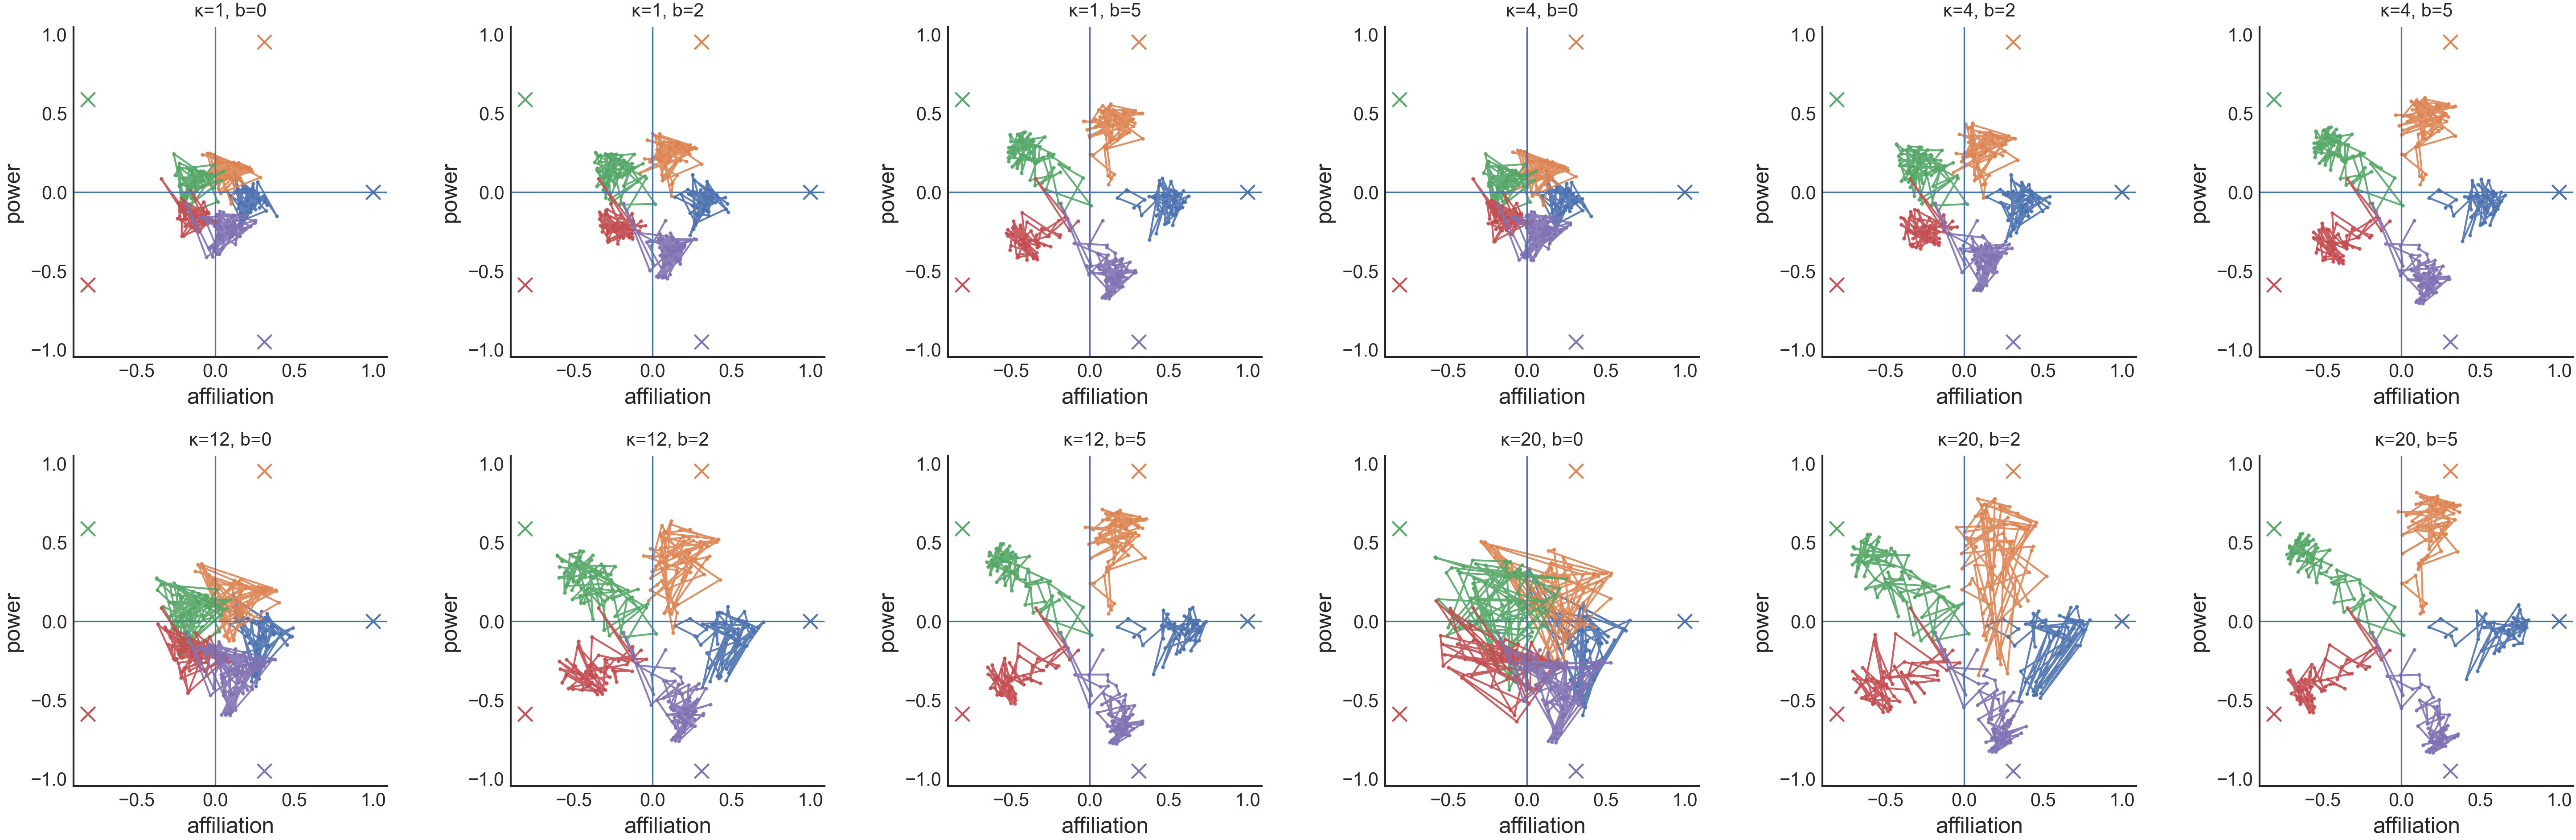

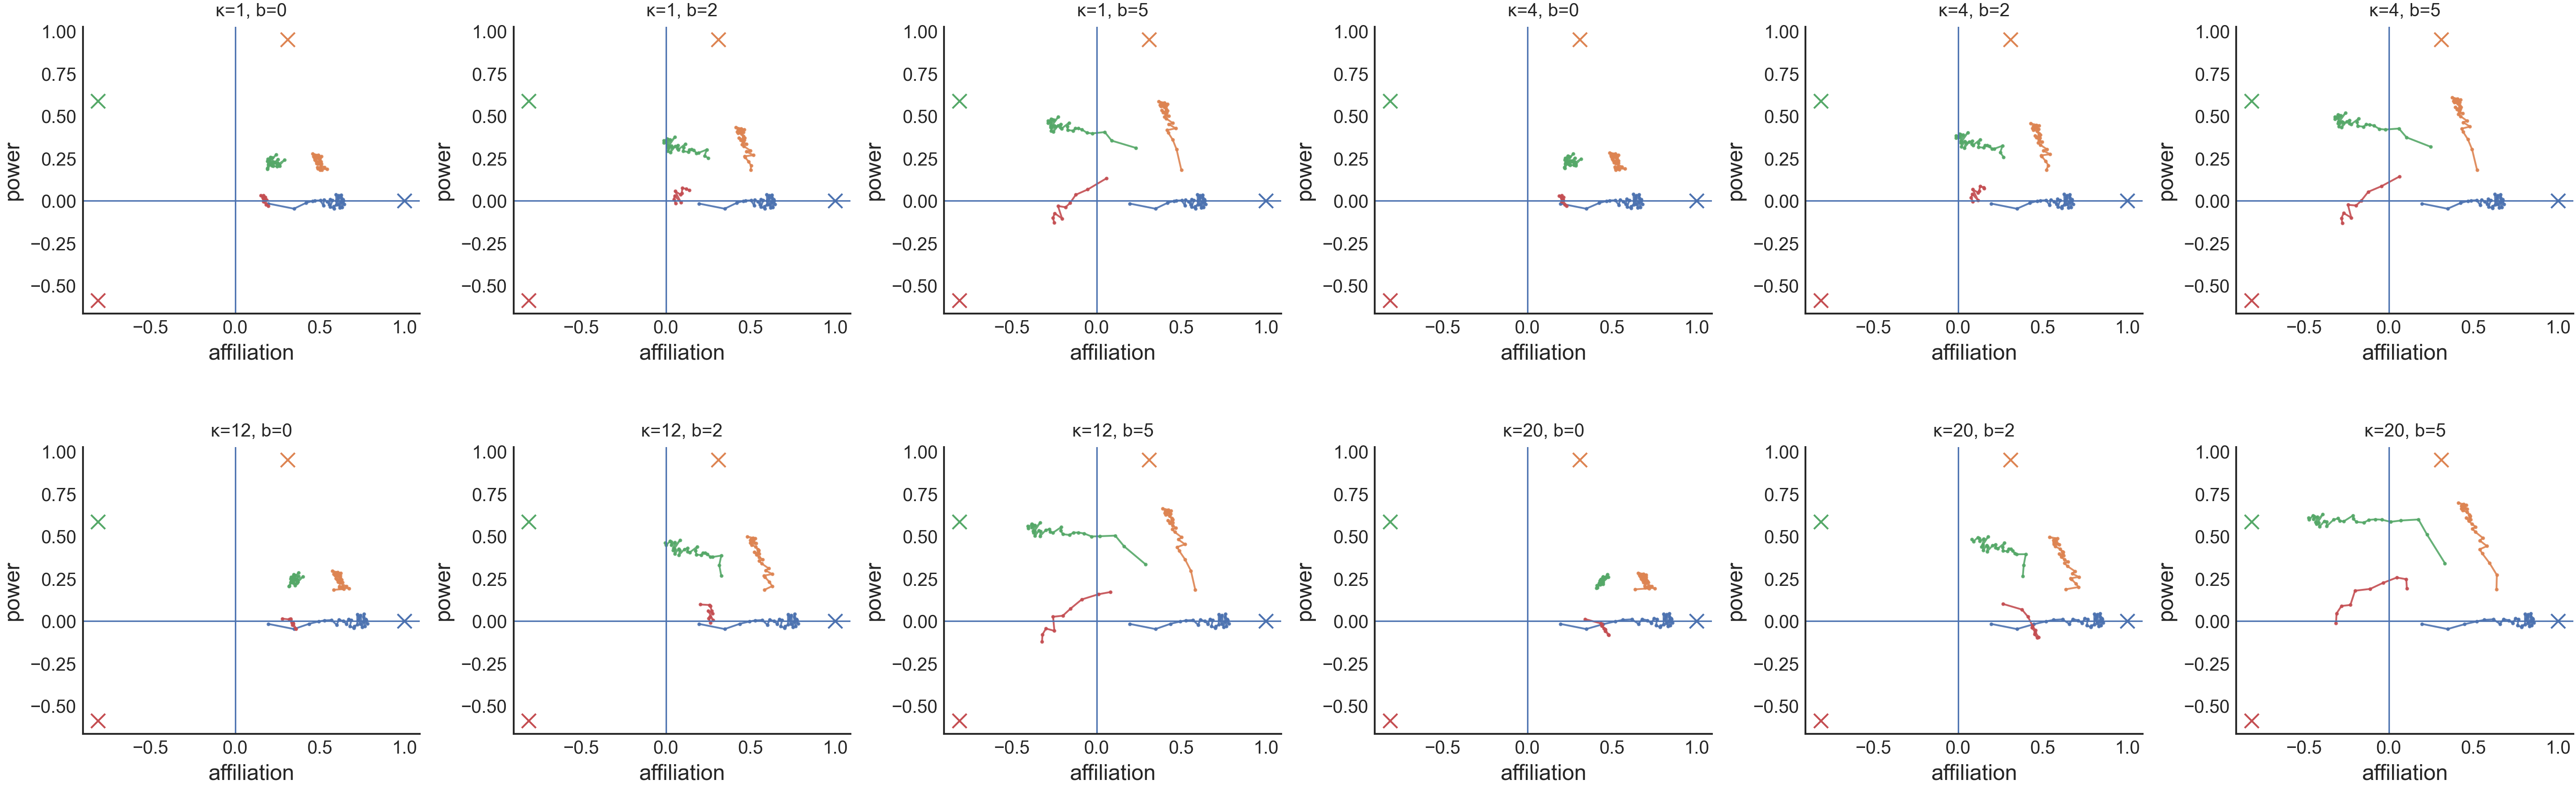

In [10]:
def plot_trajectories_ax(
    ax,
    df: pd.DataFrame,
    base_true: np.ndarray,
    *,
    title: str,
    show_legend: bool = False,
    legend_max_chars: int = 8,
    alpha_path: float = 0.9,
    lw: float = 1.0,
    ms: float = 2.0,
):
    chars = sorted(df["char"].unique())
    for c in chars:
        sub = df[df["char"] == c]
        ax.plot(
            sub["mu_affil"].to_numpy(float),
            sub["mu_power"].to_numpy(float),
            marker=".",
            markersize=ms,
            linewidth=lw,
            alpha=alpha_path,
            label=f"c{c}",
        )
        ax.scatter([base_true[c, 0]], [base_true[c, 1]], marker="x", s=60)

    ax.axhline(0, linewidth=0.8)
    ax.axvline(0, linewidth=0.8)
    ax.set_aspect("equal", "box")
    ax.set_xlabel("affiliation")
    ax.set_ylabel("power")
    ax.set_title(title, fontsize=10)

    if show_legend:
        # avoid enormous legends when n_char is large
        if len(chars) <= legend_max_chars:
            ax.legend(loc="best", fontsize=8, frameon=False)
        else:
            ax.legend_.remove() if ax.legend_ else None

def simulate_regime(
    *,
    regime_name: str,
    model_spec: dict,
    n_trials: int,
    n_char: int,
    schedule_mode: str,
    block_len: int,
    choice_mode: str,
    choice_kwargs: dict,
    seeds: list[int],
    aggregate: str = "mean",  # "mean" | "single" | "overlay"
):
    dfs = []
    base_true_ref = None

    for k, seed in enumerate(seeds):
        df, base_true, _state = run_simulation(
            regime_name=regime_name,
            model_spec=model_spec,
            choice_mode=choice_mode,
            choice_kwargs=choice_kwargs,
            n_trials=n_trials,
            n_char=n_char,
            schedule_mode=schedule_mode,
            block_len=block_len,
            seed=int(seed),
        )
        df = df.copy()
        df["sim"] = k
        dfs.append(df)
        base_true_ref = base_true

    if aggregate == "single":
        return dfs[0], base_true_ref

    if aggregate == "overlay":
        return pd.concat(dfs, ignore_index=True), base_true_ref

    if aggregate == "mean":
        big = pd.concat(dfs, ignore_index=True)
        # average mu and retrieval diagnostics; keep x/true for completeness (mean true == true)
        mean_df = (
            big.groupby(["t", "char"], as_index=False)
               .agg(
                   mu_affil=("mu_affil", "mean"),
                   mu_power=("mu_power", "mean"),
                   retr_affil=("retr_affil", "mean"),
                   retr_power=("retr_power", "mean"),
                   entropy=("entropy", "mean"),
                   n_eff=("n_eff", "mean"),
                   other_mass=("other_mass", "mean"),
                   surprise=("surprise", "mean"),
                   mem_n=("mem_n", "mean"),
                   true_affil=("true_affil", "mean"),
                   true_power=("true_power", "mean"),
               )
        )
        mean_df["regime"] = regime_name
        return mean_df, base_true_ref

    raise ValueError("aggregate must be 'mean', 'single', or 'overlay'")

def plot_regime_grid(
    regimes: dict[str, dict],
    *,
    n_char: int = 8,
    n_trials: int = 600,
    schedule_mode: str = "blocks",
    block_len: int = 30,
    choice_mode: str = "continuous",
    choice_kwargs: dict | None = None,
    seeds: list[int] | None = None,
    aggregate: str = "mean",          # "mean" | "single" | "overlay"
    max_cols: int = 6,
    figsize_per_ax: tuple[float, float] = (3.3, 3.3),
    show_legend: bool = False,
):
    choice_kwargs = {} if choice_kwargs is None else dict(choice_kwargs)
    seeds = [0] if seeds is None else list(seeds)

    names = list(regimes.keys())
    n_panels = len(names)
    n_cols = min(int(max_cols), n_panels)
    n_rows = int(np.ceil(n_panels / n_cols))

    fig_w = figsize_per_ax[0] * n_cols
    fig_h = figsize_per_ax[1] * n_rows
    fig, axs = plt.subplots(n_rows, n_cols, figsize=(fig_w, fig_h), squeeze=False)

    for i, name in enumerate(names):
        r = i // n_cols
        c = i % n_cols
        ax = axs[r, c]

        spec = regimes[name]
        df_plot, base_true = simulate_regime(
            regime_name=name,
            model_spec=spec,
            n_trials=n_trials,
            n_char=n_char,
            schedule_mode=schedule_mode,
            block_len=block_len,
            choice_mode=choice_mode,
            choice_kwargs=choice_kwargs,
            seeds=seeds,
            aggregate=aggregate,
        )

        # If overlay, reduce alpha so it doesn't saturate
        alpha_path = 0.35 if aggregate == "overlay" and len(seeds) > 1 else 0.9
        plot_trajectories_ax(
            ax,
            df_plot,
            base_true,
            title=name,
            show_legend=show_legend,
            alpha_path=alpha_path,
        )

    # turn off unused axes
    for j in range(n_panels, n_rows * n_cols):
        r = j // n_cols
        c = j % n_cols
        axs[r, c].axis("off")

    fig.tight_layout()
    plt.show()
    return fig

def make_kappa_bias_grid(
    kappas=(1.0, 4.0, 12.0, 20.0),
    biases=(0.0, 1.0, 3.0, 6.0),
    *,
    alpha=0.20,
):
    regimes = {}
    for k in kappas:
        for b in biases:
            name = f"κ={k:g}, b={b:g}"
            regimes[name] = make_model_spec_episodic(alpha=alpha, kappa=float(k), same_char_bias=float(b))
    return regimes

# More systematic regimes
regimes = make_kappa_bias_grid(
    kappas=(1.0, 4.0, 12.0, 20.0),
    biases=(0.0, 2.0, 5.0),
    alpha=0.20,
)

# Plot grid with <=6 columns, 10 characters, 5 seeds per regime
plot_regime_grid(
    regimes,
    n_char=5,
    n_trials=100,
    schedule_mode="interleave",
    block_len=30,
    choice_mode="continuous",
    choice_kwargs=dict(noise_sd=0.25),
    seeds=[0, 1, 2, 3, 4],     # replicates
    aggregate="mean",          # recommended
    max_cols=6,
    show_legend=False,
);

plot_regime_grid(
    regimes,
    n_char=5,
    n_trials=100,
    schedule_mode="blocks",
    block_len=30,
    choice_mode="continuous",
    choice_kwargs=dict(noise_sd=0.25),
    seeds=[0, 1, 2, 3, 4],     # replicates
    aggregate="mean",          # recommended
    max_cols=6,
    show_legend=False,
);


### real data

Subjects: 100%|██████████| 79/79 [00:23<00:00,  3.31it/s]


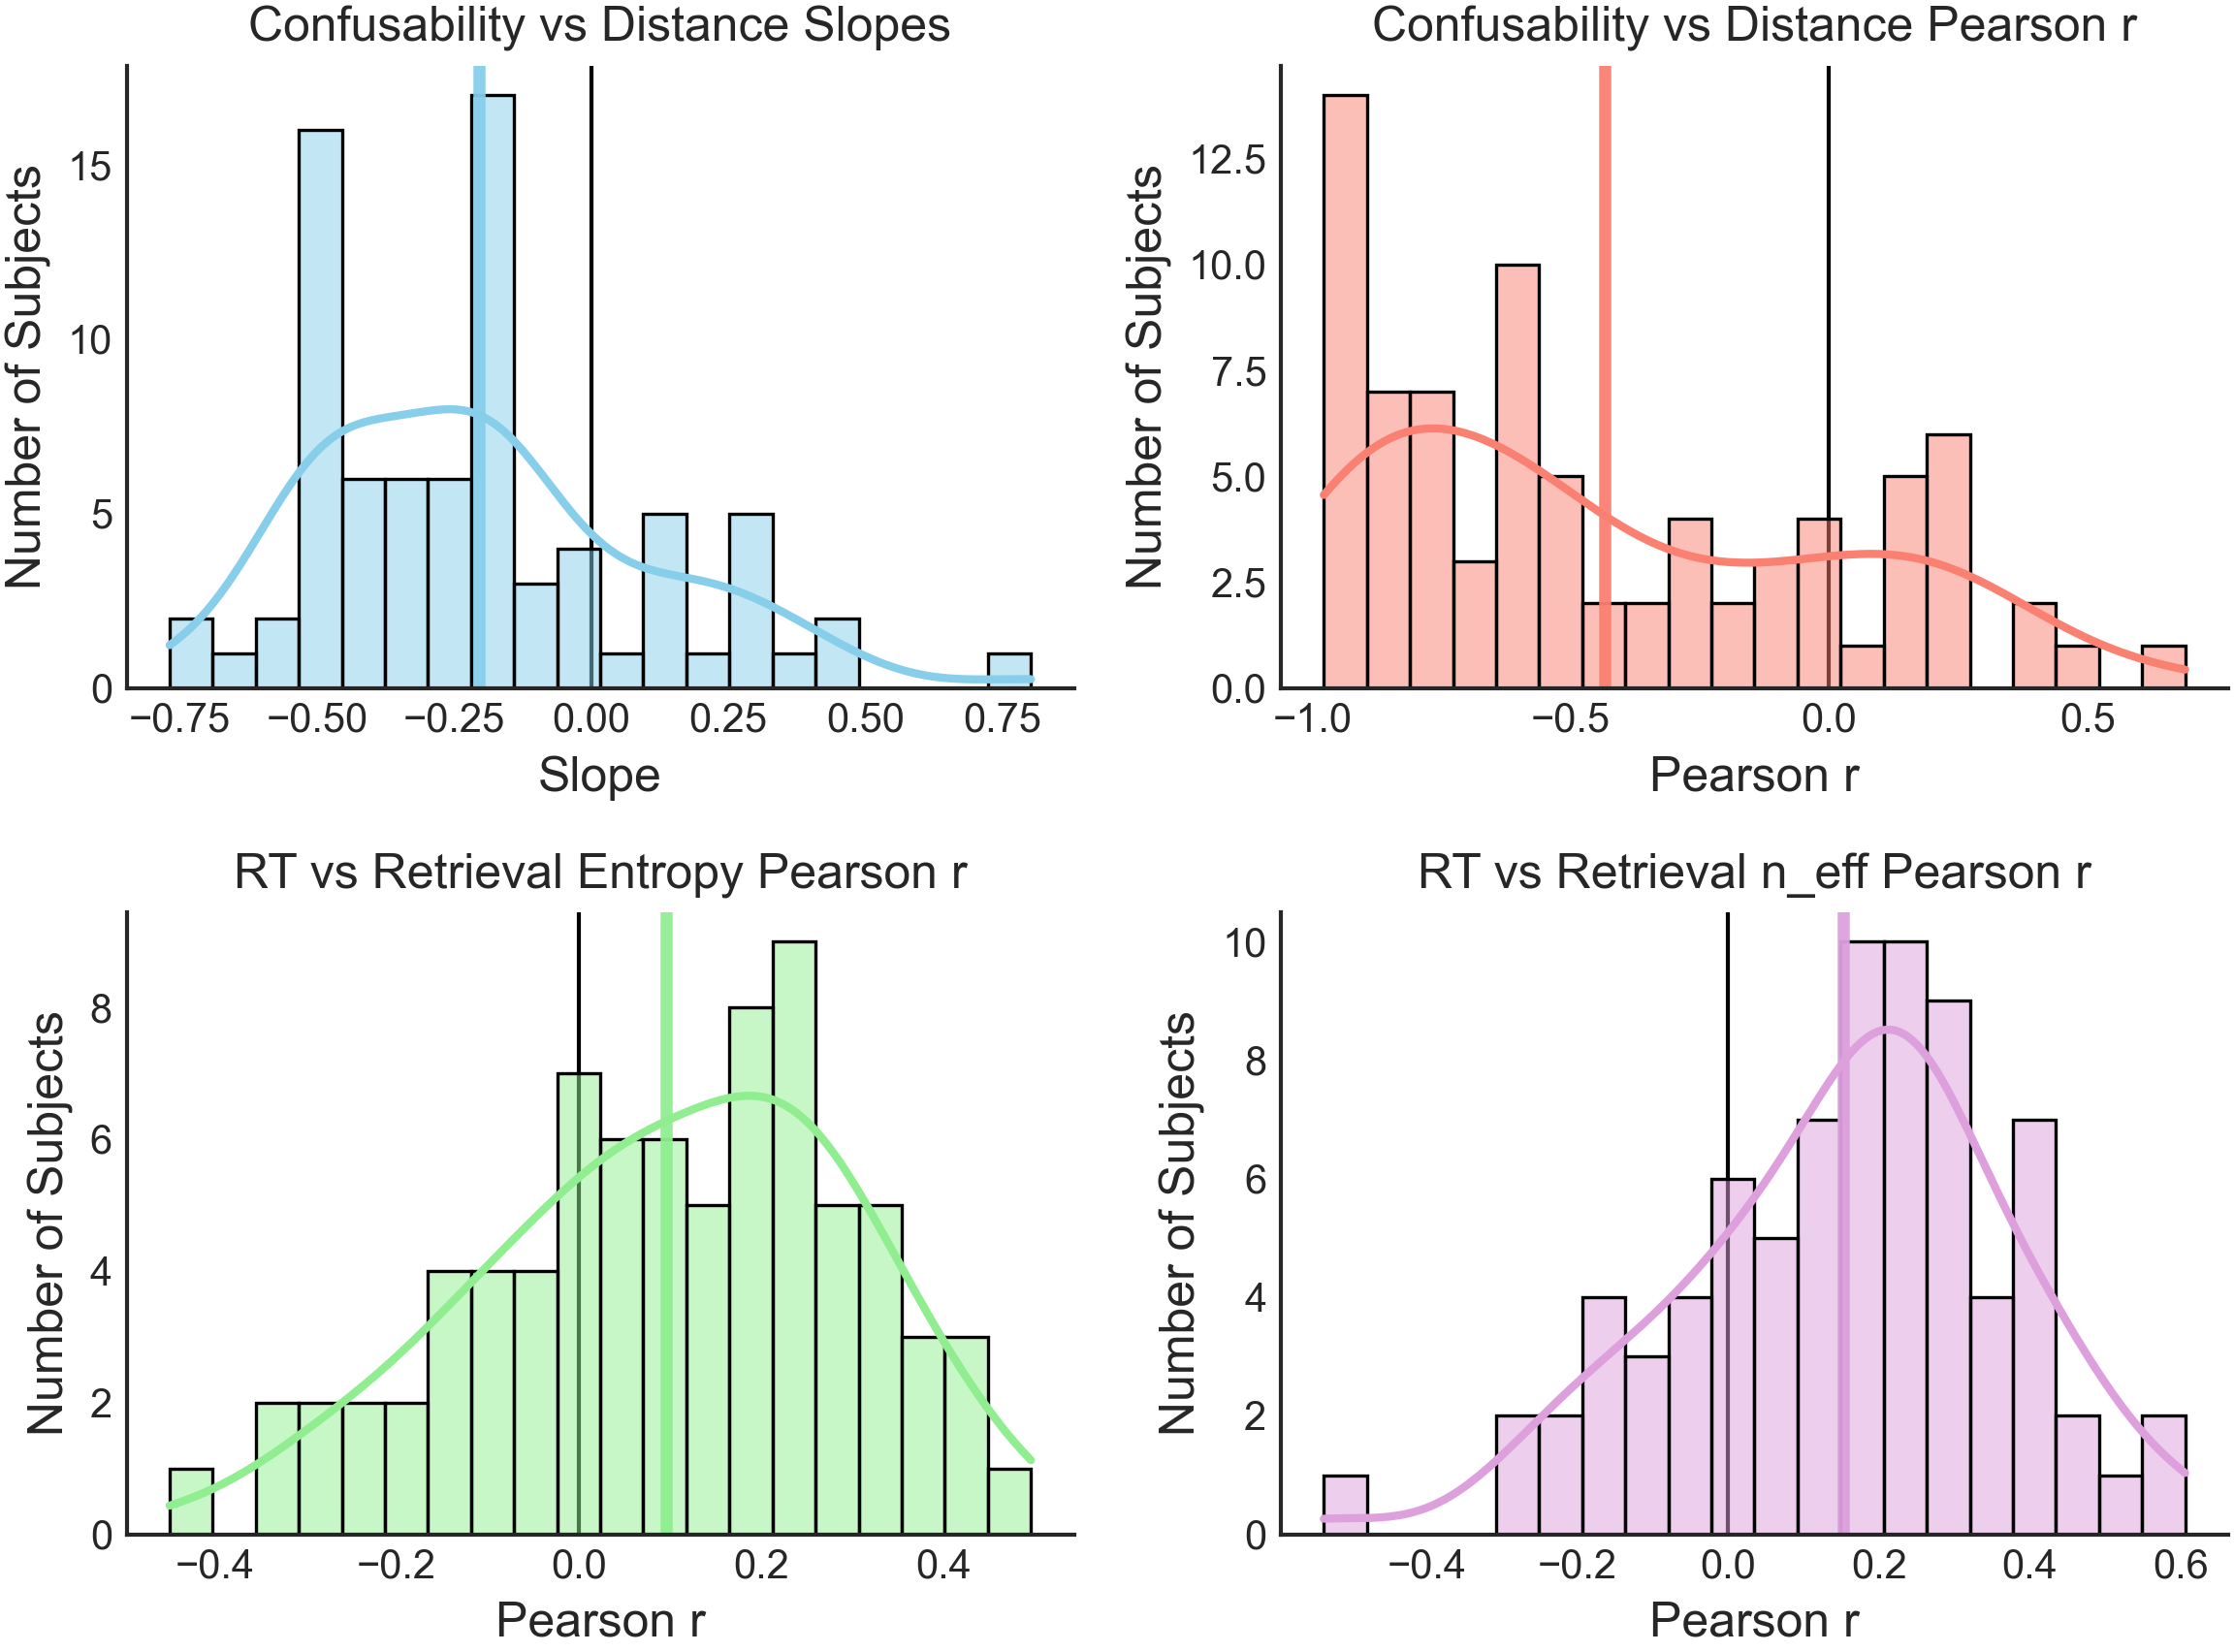

In [7]:
spec = make_model_spec_episodic(kappa=4.0, same_char_bias=0.5, alpha=None, restrict="all")
subject_metrics = summarize_subjects(incl_subs, model_spec=spec, neutrals=False, normalize=True)

#--------------- plotting 

def hist_kde_with_mean(
    ax,
    series,
    *,
    color,
    title,
    xlabel,
    ylabel="Number of Subjects",
    bins=20,
):
    x = pd.to_numeric(series, errors="coerce").dropna().to_numpy(float)
    sns.histplot(
        x=x,
        ax=ax,
        bins=bins,
        kde=True,
        stat="count",
        edgecolor="black",
        alpha=0.5,
        color=color,
        line_kws=dict(linewidth=2),
    )

    m = float(np.mean(x))
    ax.axvline(m, color=color, linewidth=3, linestyle="-", alpha=0.95)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.axvline(0, color="black", linewidth=1, linestyle="-", alpha=1, zorder=-10)

fig, axs = plt.subplots(2, 2, figsize=(8, 6))

hist_kde_with_mean(
    axs[0, 0],
    subject_metrics["conf_slope"],
    color="skyblue",
    title="Confusability vs Distance Slopes",
    xlabel="Slope",
)

hist_kde_with_mean(
    axs[0, 1],
    subject_metrics["conf_r"],
    color="salmon",
    title="Confusability vs Distance Pearson r",
    xlabel="Pearson r",
)

hist_kde_with_mean(
    axs[1, 0],
    subject_metrics["rt_r_entropy"],
    color="lightgreen",
    title="RT vs Retrieval Entropy Pearson r",
    xlabel="Pearson r",
)

hist_kde_with_mean(
    axs[1, 1],
    subject_metrics["rt_r_neff"],
    color="plum",
    title="RT vs Retrieval n_eff Pearson r",
    xlabel="Pearson r",
)

plt.tight_layout()

### adding in better predictions
Dots

and more RT BETTER memory... i think this is an interesting constraint

In [ ]:
from scipy.stats import pearsonr, kendalltau

def compute_social_task_scores(
    df: pd.DataFrame,
    state: dict | None = None,
    *,
    char_col: str = "character_role_num",
    rt_col: str = "reaction_time",
    kappa: float | None = None,
    same_char_bias: float = 0.0,
    restrict: str = "all",          # "all" | "same"
    placement: pd.Series | pd.DataFrame | dict | None = None,
    dots_prefix: str = "dots",
    role_to_name: dict | None = None,
    align: str = "none",            # "none" | "procrustes" | "affine"
    n_perm: int = 100,
    seed: int = 0,
    query_chars=None,
    eps: float = 1e-12,
) -> dict:
    """
    One-stop score extraction:
      - RT correlations with retrieval metrics (if present in df)
      - confusability-vs-distance slope (if episodic state + kappa provided)
      - post-task placement quality (if placement provided), using:
          * mapping error (mean Euclid)
          * location_closeness z vs shuffled-character null
          * RSA Kendall tau between pairwise distance vectors

    placement formats supported:
      A) "wide" (dict/Series/1-row df): columns like
           f"{dots_prefix}_affil_<name>", f"{dots_prefix}_power_<name>"
         where <name> can be role name (e.g., "first") or raw character id.
      B) "long" (DataFrame): columns [char_col, f"{dots_prefix}_affil", f"{dots_prefix}_power"]

    Returns a dict with:
      - rt_r_entropy, rt_r_neff
      - conf_slope, conf_r
      - placement: dict of metrics for multiple task coordinate sources
      - char_table: per-character coords + error (filterable via query_chars)
    """
    if df is None or len(df) == 0:
        raise ValueError("df is empty")

    if align not in {"none", "procrustes", "affine"}:
        raise ValueError("align must be one of {'none','procrustes','affine'}")

    if restrict not in {"all", "same"}:
        raise ValueError("restrict must be 'all' or 'same'")

    # stable trial order
    order_col = "global_t" if "global_t" in df.columns else ("t" if "t" in df.columns else None)
    ep = df.sort_values(order_col).reset_index(drop=True) if order_col else df.reset_index(drop=True)

    if char_col not in ep.columns:
        raise KeyError(f"df is missing char_col={char_col!r}")

    # reconstruct the same "first-appearance" encoding used by pd.unique
    char_ids = ep[char_col].to_numpy()
    uniq_chars = pd.unique(char_ids)
    char_to_idx = {c: i for i, c in enumerate(uniq_chars)}
    idx_to_char = {i: c for c, i in char_to_idx.items()}
    n_char = int(len(uniq_chars))

    # ---- small local helpers
    def _pearson(x, y):
        x = np.asarray(x, float); y = np.asarray(y, float)
        m = np.isfinite(x) & np.isfinite(y)
        if m.sum() < 3:
            return np.nan
        return float(pearsonr(x[m], y[m])[0])

    def _linreg_slope(x, y):
        x = np.asarray(x, float); y = np.asarray(y, float)
        m = np.isfinite(x) & np.isfinite(y)
        if m.sum() < 3:
            return np.nan
        x = x[m]; y = y[m]
        xc = x - x.mean()
        denom = float(xc @ xc)
        if denom <= 0:
            return np.nan
        return float((xc @ (y - y.mean())) / denom)

    def _pairwise_distvec(X):
        X = np.asarray(X, float)
        if X.ndim != 2 or X.shape[0] < 2:
            return np.array([], float)
        D = np.linalg.norm(X[:, None, :] - X[None, :, :], axis=2)
        iu = np.triu_indices(D.shape[0], k=1)
        return D[iu]

    def _fit_transform(task_xy, place_xy):
        X = np.asarray(task_xy, float)
        Y = np.asarray(place_xy, float)
        if align == "none":
            return X

        if align == "affine":
            A = np.c_[X, np.ones((X.shape[0], 1))]
            B, *_ = np.linalg.lstsq(A, Y, rcond=None)   # (3,2)
            return A @ B

        # procrustes similarity transform (rotation+scale+translation)
        Xc = X - X.mean(axis=0, keepdims=True)
        Yc = Y - Y.mean(axis=0, keepdims=True)
        ssx = float((Xc * Xc).sum())
        if ssx < eps:
            return X
        M = Xc.T @ Yc
        U, S, Vt = np.linalg.svd(M, full_matrices=False)
        R = U @ Vt
        scale = float(S.sum() / ssx)
        return scale * (Xc @ R) + Y.mean(axis=0, keepdims=True)

    def _mapping_metrics(task_xy, place_xy):
        X = np.asarray(task_xy, float)
        Y = np.asarray(place_xy, float)
        m = np.isfinite(X).all(axis=1) & np.isfinite(Y).all(axis=1)
        X = X[m]; Y = Y[m]
        if X.shape[0] < 2:
            return dict(
                n_used=int(X.shape[0]),
                map_error=np.nan,
                null_mean=np.nan,
                null_sd=np.nan,
                location_closeness=np.nan,
                rsa_tau=np.nan,
                affil_r=np.nan,
                power_r=np.nan,
            ), m

        Xt = _fit_transform(X, Y)
        d = np.linalg.norm(Xt - Y, axis=1)
        map_error = float(np.mean(d))

        rng = np.random.default_rng(int(seed))
        null = np.empty(int(n_perm), float)
        for i in range(int(n_perm)):
            perm = rng.permutation(Xt.shape[0])
            null[i] = float(np.mean(np.linalg.norm(Xt - Y[perm], axis=1)))

        null_mean = float(np.mean(null))
        null_sd = float(np.std(null, ddof=1)) if null.size > 1 else np.nan
        location_closeness = float((null_mean - map_error) / (null_sd + eps)) if np.isfinite(null_sd) else np.nan

        rsa_tau = np.nan
        if Xt.shape[0] >= 3:
            dv_task = _pairwise_distvec(Xt)
            dv_place = _pairwise_distvec(Y)
            if dv_task.size == dv_place.size and dv_task.size >= 3:
                rsa_tau = float(kendalltau(dv_task, dv_place, nan_policy="omit")[0])

        return dict(
            n_used=int(Xt.shape[0]),
            map_error=map_error,
            null_mean=null_mean,
            null_sd=null_sd,
            location_closeness=location_closeness,
            rsa_tau=rsa_tau,
            affil_r=_pearson(Xt[:, 0], Y[:, 0]),
            power_r=_pearson(Xt[:, 1], Y[:, 1]),
        ), m

    # ---- outputs
    out = dict(n_trials=int(len(ep)), n_char=int(n_char))

    # RT correlations
    if rt_col in ep.columns and {"retrieval_entropy", "retrieval_neff"}.issubset(ep.columns):
        out["rt_r_entropy"] = _pearson(ep[rt_col], ep["retrieval_entropy"])
        out["rt_r_neff"] = _pearson(ep[rt_col], ep["retrieval_neff"])
    else:
        out["rt_r_entropy"] = np.nan
        out["rt_r_neff"] = np.nan

    # confusability slope vs distance (episodic)
    out["conf_slope"] = np.nan
    out["conf_r"] = np.nan
    if (state is not None) and (kappa is not None) and ("mem_vecs" in state) and ("mem_chars" in state):
        mu = np.asarray(state.get("mu", np.zeros((n_char, 2))), float)[:n_char]
        mem_vecs = np.asarray(state.get("mem_vecs", []), float)
        mem_chars = np.asarray(state.get("mem_chars", []), int)

        if mem_vecs.ndim == 2 and mem_vecs.shape[1] == 2 and mem_vecs.shape[0] == mem_chars.shape[0] and mem_vecs.shape[0] > 0:
            M = np.zeros((n_char, n_char), float)

            for cue in range(n_char):
                q = mu[cue].reshape(2,)
                mask = (mem_chars == cue) if restrict == "same" else np.ones(mem_chars.shape[0], bool)
                if not np.any(mask):
                    continue

                E = mem_vecs[mask]
                C = mem_chars[mask]
                sims = E @ q
                bias = (C == cue).astype(float) * float(same_char_bias)

                scores = float(kappa) * sims + bias
                scores = scores - np.max(scores)
                w = np.exp(scores)
                w = w / (w.sum() + eps)

                for j in range(n_char):
                    M[cue, j] = float(w[C == j].sum())

            Coff = M.copy()
            np.fill_diagonal(Coff, 0.0)
            row_sums = Coff.sum(axis=1, keepdims=True)
            with np.errstate(divide="ignore", invalid="ignore"):
                Cprob = Coff / row_sums
            Cprob[~np.isfinite(Cprob)] = 0.0

            D = np.linalg.norm(mu[:, None, :] - mu[None, :, :], axis=2)

            xs, ys = [], []
            for i in range(n_char):
                for j in range(i + 1, n_char):
                    xs.append(float(D[i, j]))
                    ys.append(float(0.5 * (Cprob[i, j] + Cprob[j, i])))
            xs = np.asarray(xs, float); ys = np.asarray(ys, float)
            out["conf_slope"] = _linreg_slope(xs, ys)
            out["conf_r"] = _pearson(xs, ys)

    # post-task placements (mapping quality)
    out["placement"] = {}
    out["char_table"] = None

    if placement is not None:
        # default matches your project’s role naming convention (1..6):contentReference[oaicite:1]{index=1}
        if role_to_name is None:
            role_to_name = {1: "first", 2: "second", 3: "assistant", 4: "powerful", 5: "boss", 6: "neutral"}

        # normalize placement input
        placement_row = None
        placement_long = None
        if isinstance(placement, pd.DataFrame):
            if len(placement) == 1 and (char_col not in placement.columns):
                placement_row = placement.iloc[0].to_dict()
            else:
                placement_long = placement
        elif isinstance(placement, pd.Series):
            placement_row = placement.to_dict()
        elif isinstance(placement, dict):
            placement_row = dict(placement)
        else:
            raise TypeError("placement must be dict, Series, or DataFrame")

        # build placement array aligned to char_idx
        Y = np.full((n_char, 2), np.nan, float)

        if placement_long is not None and {char_col, f"{dots_prefix}_affil", f"{dots_prefix}_power"}.issubset(placement_long.columns):
            tmp = placement_long[[char_col, f"{dots_prefix}_affil", f"{dots_prefix}_power"]]
            for cid, a, p in tmp.itertuples(index=False, name=None):
                if cid in char_to_idx:
                    Y[char_to_idx[cid], 0] = float(a)
                    Y[char_to_idx[cid], 1] = float(p)
        else:
            for cid, idx in char_to_idx.items():
                suffix = role_to_name.get(int(cid), cid) if isinstance(cid, (int, np.integer)) else cid
                suffix = str(suffix)
                cands = [
                    (f"{dots_prefix}_affil_{suffix}", f"{dots_prefix}_power_{suffix}"),
                    (f"{dots_prefix}_affil_{cid}",    f"{dots_prefix}_power_{cid}"),
                ]
                for ca, cp in cands:
                    if placement_row is not None and (ca in placement_row) and (cp in placement_row):
                        Y[idx, 0] = float(placement_row[ca])
                        Y[idx, 1] = float(placement_row[cp])
                        break

        # task coordinate sources (we compute several; you can pick whichever you want)
        coord_sets = {}

        if {"pos_affil", "pos_power"}.issubset(ep.columns):
            g = ep.groupby(char_col, sort=False, observed=True)

            # average position over the task: "average location from the task"
            mean_pos = g[["pos_affil", "pos_power"]].mean()
            X_mean = np.full((n_char, 2), np.nan, float)
            for cid, row in mean_pos.iterrows():
                if cid in char_to_idx:
                    X_mean[char_to_idx[cid]] = row.to_numpy(float)
            coord_sets["task_pos_mean"] = X_mean

            # end position
            end_pos = g[["pos_affil", "pos_power"]].last()
            X_end = np.full((n_char, 2), np.nan, float)
            for cid, row in end_pos.iterrows():
                if cid in char_to_idx:
                    X_end[char_to_idx[cid]] = row.to_numpy(float)
            coord_sets["task_pos_end"] = X_end

        if state is not None and "mu" in state:
            mu = np.asarray(state["mu"], float)
            if mu.ndim == 2 and mu.shape[1] == 2:
                coord_sets["model_mu_final"] = mu[:n_char].copy()

        # compute placement metrics for each coord set
        for name, X in coord_sets.items():
            metrics, _ = _mapping_metrics(X, Y)
            out["placement"][name] = metrics

        # build per-character table (for querying character locations)
        base_name = "task_pos_mean" if "task_pos_mean" in coord_sets else next(iter(coord_sets.keys()), None)
        if base_name is not None:
            X = coord_sets[base_name]
            m = np.isfinite(X).all(axis=1) & np.isfinite(Y).all(axis=1)
            Xt = _fit_transform(X[m], Y[m]) if m.sum() else np.empty((0, 2))
            Xtf = np.full_like(X, np.nan, float)
            Xtf[m] = Xt

            char_table = pd.DataFrame({
                "char_idx": np.arange(n_char, dtype=int),
                "character": [idx_to_char[i] for i in range(n_char)],
                "task_affil": X[:, 0],
                "task_power": X[:, 1],
                "task_affil_aligned": Xtf[:, 0],
                "task_power_aligned": Xtf[:, 1],
                "place_affil": Y[:, 0],
                "place_power": Y[:, 1],
            })
            char_table["euclid_err"] = np.sqrt(
                (char_table["task_affil_aligned"] - char_table["place_affil"]) ** 2 +
                (char_table["task_power_aligned"] - char_table["place_power"]) ** 2
            )

            if query_chars is not None:
                qc = set(query_chars if isinstance(query_chars, (list, tuple, set, pd.Index)) else [query_chars])
                def _as_name(cid):
                    if isinstance(cid, (int, np.integer)) and int(cid) in role_to_name:
                        return role_to_name[int(cid)]
                    return str(cid)
                qc_names = set(map(_as_name, qc))
                keep = [(cid in qc) or (_as_name(cid) in qc_names) for cid in char_table["character"]]
                char_table = char_table[np.array(keep, bool)].reset_index(drop=True)

            out["char_table"] = char_table

    return out

# # after fit_subject(...)
# df, state, meta = fit_subject(sub_id, model_spec=model_spec)

# # grab that subject’s post-task placements row from your wide “data” table
# # (must contain dots_affil_first, dots_power_first, ... etc)
# placement_row = data.loc[data["sub_id"] == sub_id].iloc[0]

# scores = compute_social_task_scores(
#     df,
#     state,
#     kappa=model_spec.get("kappa", None),
#     same_char_bias=float(model_spec.get("same_char_bias", 0.0)),
#     restrict=str(model_spec.get("restrict", "all")),
#     placement=placement_row,     # wide row or dict
#     dots_prefix="dots",
#     align="none",                # start with none (matches published approach)
#     n_perm=100,
#     seed=0,
# )

# # the “placement quality” score you asked for:
# scores["placement"]["task_pos_mean"]["location_closeness"]

# # query the location/error of specific characters:
# scores["char_table"].query("character == 1")      # if your ids are ints
# # or:
# compute_social_task_scores(df, state, kappa=model_spec["kappa"], placement=placement_row,
#                            query_chars=["first"])["char_table"]
